<a href="https://colab.research.google.com/github/Arnav613Gupta/deep_learning/blob/main/Ai_sustainability_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Importing Dataset**

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [5]:
!kaggle datasets download -d rishabhsnip/earth-observation-delhi-airshed

Dataset URL: https://www.kaggle.com/datasets/rishabhsnip/earth-observation-delhi-airshed
License(s): CC0-1.0
 53% 152M/289M [00:00<00:00, 1.58GB/s]
100% 289M/289M [00:00<00:00, 961MB/s] 


In [6]:
import zipfile
zip_ref = zipfile.ZipFile('/content/earth-observation-delhi-airshed.zip', 'r')
zip_ref.extractall("/content")
zip_ref.close()

# **Spatial Reasoning & Data Filtering**

In [7]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import rasterio
from rasterio.windows import Window
from shapely.geometry import Point, box
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import seaborn as sns
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image

In [8]:
ncr = gpd.read_file("/content/delhi_ncr_region.geojson")
print(ncr.crs)

EPSG:4326


In [9]:
ncr_utm = ncr.to_crs(epsg=32644)

In [10]:
minx, miny, maxx, maxy = ncr_utm.total_bounds

grid_size = 60000  # 60 km in meters

grid_cells = []
x = minx
while x < maxx:
    y = miny
    while y < maxy:
        grid_cells.append(box(x, y, x + grid_size, y + grid_size))
        y += grid_size
    x += grid_size

grid = gpd.GeoDataFrame(grid_cells, columns=['geometry'], crs=ncr_utm.crs)

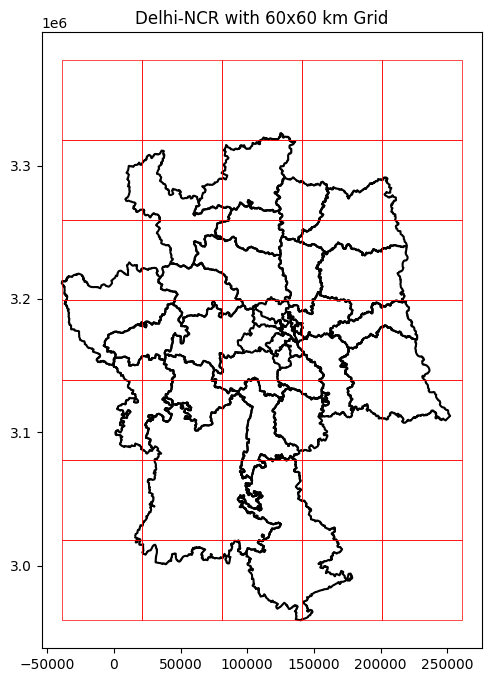

In [11]:
fig, ax = plt.subplots(figsize=(8,8))
ncr_utm.boundary.plot(ax=ax, color='black')
grid.boundary.plot(ax=ax, color='red', linewidth=0.5)
plt.title("Delhi-NCR with 60x60 km Grid")
plt.show()

In [12]:
# Get all PNG images
image_paths = glob.glob("/content/rgb/*.png")
print("Total images before filtering:", len(image_paths))

# Extract all points at once
points = []
for path in image_paths:
    name = os.path.basename(path).replace(".png", "")
    lat, lon = map(float, name.split("_"))
    points.append(Point(lon, lat))

# Create GeoDataFrame
points_gdf = gpd.GeoDataFrame(geometry=points, crs="EPSG:4326")

# Convert once to UTM
points_gdf = points_gdf.to_crs(epsg=32644)

# Merge NCR polygons
ncr_polygon = ncr_utm.geometry.union_all()

# Check which points are inside
inside_mask = points_gdf.within(ncr_polygon)

# Filter valid images
valid_images = [image_paths[i] for i in range(len(image_paths)) if inside_mask.iloc[i]]

print("Total images after filtering:", len(valid_images))

Total images before filtering: 9216
Total images after filtering: 8015


## **Label Construction & Dataset Preparation**

In [13]:
lc = rasterio.open("/content/worldcover_bbox_delhi_ncr_2021.tif")

In [14]:
def extract_patch(center_lat, center_lon):
    point = gpd.GeoSeries([Point(center_lon, center_lat)], crs="EPSG:4326")
    point_utm = point.to_crs(lc.crs)

    x, y = point_utm.geometry.x.iloc[0], point_utm.geometry.y.iloc[0]
    row, col = lc.index(x, y)

    window = Window(col-64, row-64, 128, 128)
    patch = lc.read(1, window=window)

    return patch

In [15]:
def extract_patch(center_lat, center_lon):
    point = gpd.GeoSeries([Point(center_lon, center_lat)], crs="EPSG:4326")
    point_utm = point.to_crs(lc.crs)

    x = point_utm.geometry.x.iloc[0]
    y = point_utm.geometry.y.iloc[0]

    row, col = lc.index(x, y)

    # Check bounds
    if row-64 < 0 or col-64 < 0:
        return None
    if row+64 > lc.height or col+64 > lc.width:
        return None

    window = rasterio.windows.Window(col-64, row-64, 128, 128)
    patch = lc.read(1, window=window)

    return patch

In [17]:
from scipy.stats import mode
labels = []
image_list = []

for path in valid_images:
    name = os.path.basename(path).replace(".png", "")

    # Your format: latitude_longitude
    lat_str, lon_str = name.split("_")
    lat, lon = float(lat_str), float(lon_str)

    patch = extract_patch(lat, lon)

    # Make sure patch is valid
    if patch is None or patch.size == 0:
        continue

    dominant_class = mode(patch.flatten(), keepdims=True)[0][0]

    labels.append(dominant_class)
    image_list.append(path)

print("Total labeled images:", len(labels))

Total labeled images: 8015


In [18]:
def map_label(code):
    if code == 50:
        return "Built-up"
    elif code in [10, 20, 30]:
        return "Vegetation"
    elif code == 40:
        return "Cropland"
    elif code == 80:
        return "Water"
    else:
        return "Others"

mapped_labels = [map_label(l) for l in labels]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    image_list, mapped_labels,
    test_size=0.4,
    random_state=42,
    stratify=mapped_labels)

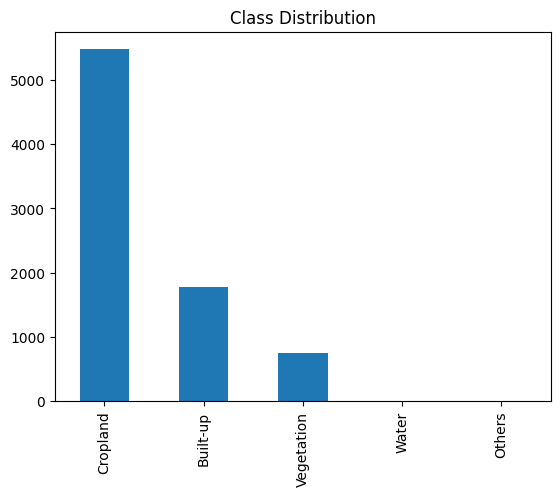

In [20]:
pd.Series(mapped_labels).value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.show()

## **MODEL TRAINING**

In [21]:
class LandUseDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        self.label_map = {label:i for i,label in enumerate(set(labels))}

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        label = self.label_map[self.labels[idx]]
        return img, label

In [22]:
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor()
])

train_dataset = LandUseDataset(X_train, y_train, transform)
test_dataset = LandUseDataset(X_test, y_test, transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [23]:
model = torchvision.models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, len(set(mapped_labels)))

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 215MB/s]


In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(10):
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 26.0471
Epoch 2, Loss: 23.9046
Epoch 3, Loss: 17.7929
Epoch 4, Loss: 7.6015
Epoch 5, Loss: 12.5748
Epoch 6, Loss: 7.5605
Epoch 7, Loss: 5.6709
Epoch 8, Loss: 10.3767
Epoch 9, Loss: 5.2097
Epoch 10, Loss: 5.3806


In [28]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

acc = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average="macro")

print("Accuracy:", acc)
print("F1 Score:", f1)

Accuracy: 0.8989394884591391
F1 Score: 0.5864170177460031


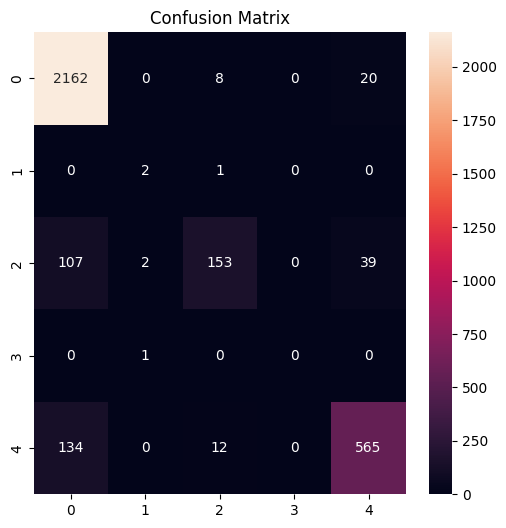

In [29]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()